In [37]:
# Credit Card Fraud Detection
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix)


Load Dataset

In [38]:
credit_card_data = pd.read_csv('creditcard.csv')

Data Validation

In [39]:
credit_card_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [40]:
# dataset informations
credit_card_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [41]:
credit_card_data = credit_card_data.dropna()

In [42]:
print("Data Loaded Successfully")
print("Shape:", credit_card_data.shape)

Data Loaded Successfully
Shape: (284807, 31)


In [43]:
# checking the number of missing values in each column
credit_card_data.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


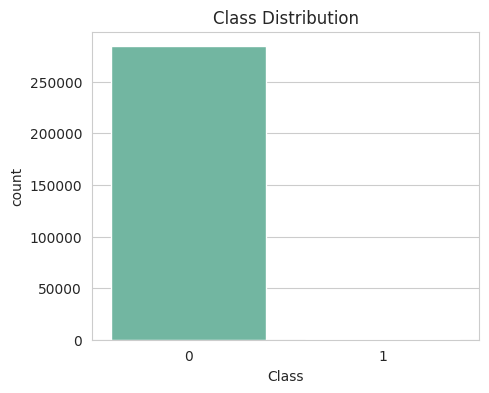

In [44]:
sns.set_style("whitegrid")

plt.figure(figsize=(5,4))
sns.countplot(data=credit_card_data, x='Class', hue='Class', palette='Set2', legend=False)
plt.title("Class Distribution")
plt.show()


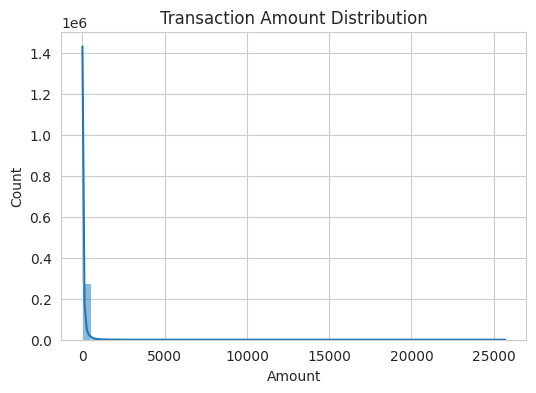


Class Distribution:
 Class
0    284315
1       492
Name: count, dtype: int64


In [45]:
# Amount distribution
plt.figure(figsize=(6,4))
sns.histplot(credit_card_data['Amount'], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.show()

print("\nClass Distribution:\n", credit_card_data['Class'].value_counts())

The dataset is highly Unbalanced

0 --> Normal Transaction

1 --> fraudulent transaction

In [46]:
# 3. Features & Target
# =============================
X = credit_card_data.drop("Class", axis=1)
y = credit_card_data["Class"]

In [47]:
# 4. Train-Test Split
# =============================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [48]:
# 5. Models
# =============================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),

}

results = []
trained_models = {}


In [49]:
# 6. Training & Evaluation
# =============================
for name, model in models.items():

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "ROC-AUC": auc
    })

    trained_models[name] = pipe


In [59]:
# 7. Results Table
# =============================
results_df = pd.DataFrame(results)
print("\nModel Comparison:\n")
print(results_df)


Model Comparison:

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.999140   0.826667  0.632653  0.716763  0.960549
1        Decision Tree  0.999087   0.734694  0.734694  0.734694  0.867118


Why ROC-AUC,
📌ROC = Receiver Operating Characteristic
📌 AUC = Area Under the Curve

Because it:

✔ Works with imbalanced data
✔ Measures ranking ability
✔ Better than accuracy for fraud

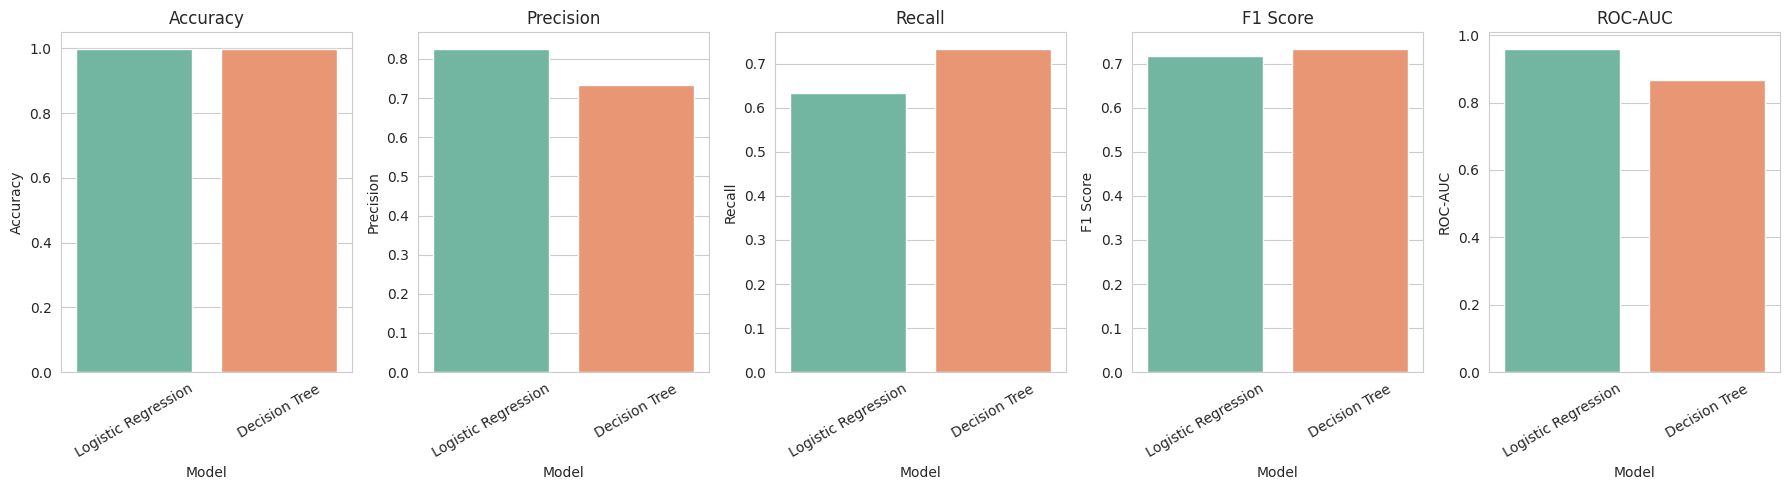

In [60]:
# 8. Graph (Clean Dashboard)
# =============================
metrics = ["Accuracy", "Precision", "Recall", "F1 Score","ROC-AUC"]

plt.figure(figsize=(18,5))

for i, metric in enumerate(metrics, 1):
    plt.subplot(1,5,i)

    sns.barplot(
        data=results_df,
        x="Model",
        y=metric,
        hue="Model",
        palette="Set2",
        legend=False
    )

    plt.xticks(rotation=30)
    plt.title(metric)

plt.tight_layout()
plt.show()


In [54]:
# 9. Best Model Selection
# =============================
best_model_name = results_df.sort_values(
    by="ROC-AUC", ascending=False
).iloc[0]["Model"]

best_model = trained_models[best_model_name]

print(f"\nBest Model: {best_model_name}")



Best Model: Logistic Regression


ROC-AUC checks: “Is the model ranking fraud higher than legit?

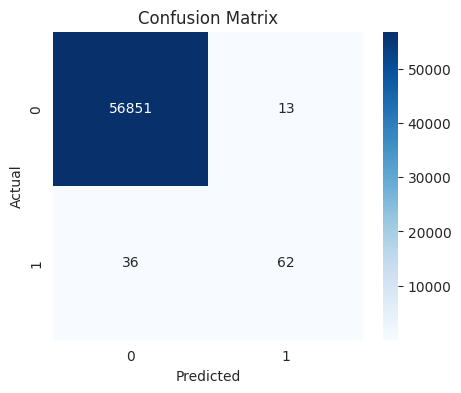

In [55]:
# 10. Confusion Matrix
# =============================
cm = confusion_matrix(y_test, best_model.predict(X_test))

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [56]:
# 11. Save Model
# =============================
joblib.dump(best_model, "fraud_model.pkl")
print("Model saved as fraud_model.pkl")

Model saved as fraud_model.pkl


In [57]:
# 12. Prediction Example
# =============================
# Take one sample from test data
sample = X_test.iloc[0:1]

prediction = best_model.predict(sample)[0]
probability = best_model.predict_proba(sample)[0][1]

print("\nPrediction Result:")

if prediction == 1:
    print(f"🚨 Fraud Transaction (Confidence: {probability:.2f})")
else:
    print(f"✅ Legit Transaction (Confidence: {1 - probability:.2f})")


Prediction Result:
✅ Legit Transaction (Confidence: 1.00)
